- Para la secuencia de números aleatorios de 50 números:
0.10  0.32  0.76  0.13  0.34  
0.37  0.04  0.64  0.74  0.24  
0.08  0.68  0.19  0.09  0.23  
0.99  0.02  0.09  0.70  0.38  
0.12  0.99  0.80  0.36  0.64  
0.66  0.74  0.34  0.76  0.36  
0.31  0.10  0.45  0.82  0.35  
0.85  0.77  0.02  0.65  0.68  
0.63  0.32  0.05  0.74  0.90  
0.73  0.42  0.03  0.64  0.35  

Se desea probar la hipótesis Ho: Proviene de una distribución uniforme en [0,1] a un nivel de significancia del 90%. Emplee la prueba de Kolmogorov Smirnov.

# Prueba de Kolmogorov-Smirnov para una secuencia de números aleatorios
# Verifica si los datos siguen una distribución uniforme en [0,1]

In [2]:
# Cargar paquetes necesarios
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("knitr")) install.packages("knitr")
if (!require("dplyr")) install.packages("dplyr")
if (!require("scales")) install.packages("scales")
if (!require("gridExtra")) install.packages("gridExtra")

library(ggplot2)
library(knitr)
library(dplyr)
library(scales)
library(gridExtra)

In [3]:
# Función para obtener los datos numéricos
ObtenerDatosNumericos <- function() {
  datos <- c(
    0.10, 0.32, 0.76, 0.13, 0.34,
    0.37, 0.04, 0.64, 0.74, 0.24,
    0.08, 0.68, 0.19, 0.09, 0.23,
    0.99, 0.02, 0.09, 0.70, 0.38,
    0.12, 0.99, 0.80, 0.36, 0.64,
    0.66, 0.74, 0.34, 0.76, 0.36,
    0.31, 0.10, 0.45, 0.82, 0.35,
    0.85, 0.77, 0.02, 0.65, 0.68,
    0.63, 0.32, 0.05, 0.74, 0.90,
    0.73, 0.42, 0.03, 0.64, 0.35
  )
  return(datos)
}

In [4]:
# Paso 1: Establecer hipótesis
MostrarHipotesis <- function() {
  cat("==============================================================\n")
  cat("PRUEBA DE KOLMOGOROV-SMIRNOV PARA DISTRIBUCIÓN UNIFORME\n")
  cat("==============================================================\n\n")

  cat("Paso 1: Establecer las hipótesis\n")
  cat("------------------------------------------\n")
  cat("H₀: Los datos provienen de una distribución uniforme en [0,1]\n")
  cat("H₁: Los datos no provienen de una distribución uniforme en [0,1]\n\n")
}

In [5]:
# Paso 2: Ordenar los datos
OrdenarMostrarDatos <- function(datos) {
  datosOrdenados <- sort(datos)
  n <- length(datosOrdenados)

  cat("Paso 2: Ordenar los datos de menor a mayor\n")
  cat("------------------------------------------\n")
  cat(sprintf("Total de datos analizados: %d\n\n", n))
  cat("Datos ordenados:\n")

  # Mostrar los datos en filas de 5 elementos
  for (i in 1:10) {
    inicio <- (i-1)*5 + 1
    fin <- min(i*5, n)
    cat(sprintf("Valores %2d-%2d: ", inicio, fin))
    cat(sprintf("%.2f ", datosOrdenados[inicio:fin]), "\n")
  }
  cat("\n")

  return(datosOrdenados)
}

In [6]:
# Paso 3-5: Calcular estadísticas
CalcularEstadisticas <- function(datosOrdenados) {
  n <- length(datosOrdenados)
  resultados <- data.frame(
    i = 1:n,
    x_i = datosOrdenados,
    Fn_x = (1:n)/n,
    Fx = datosOrdenados
  )

  # Calcular diferencias
  resultados$D_plus <- abs(resultados$Fn_x - resultados$Fx)
  resultados$D_minus <- c(0, abs(resultados$Fn_x[1:(n-1)] - resultados$Fx[2:n]))

  # Encontrar valores máximos
  dPlusMax <- max(resultados$D_plus)
  dPlusMaxIndice <- which.max(resultados$D_plus)

  dMinusMax <- max(resultados$D_minus)
  dMinusMaxIndice <- which.max(resultados$D_minus)

  cat("Paso 3-5: Calcular funciones de distribución y diferencias\n")
  cat("------------------------------------------\n")
  cat("Calculando función de distribución empírica F_n(x) y teórica F(x)...\n\n")

  return(list(
    resultados = resultados,
    dPlusMax = dPlusMax,
    dMinusMax = dMinusMax,
    dPlusMaxIndice = dPlusMaxIndice,
    dMinusMaxIndice = dMinusMaxIndice,
    n = n
  ))
}

In [7]:
# Mostrar tabla de resultados completa
MostrarTablaResultados <- function(estadisticas) {
  resultados <- estadisticas$resultados

  # Formatear los números a 4 decimales
  resultados_fmt <- resultados
  resultados_fmt[, 2:6] <- round(resultados[, 2:6], 4)

  # Renombrar columnas para la presentación
  names(resultados_fmt) <- c(
    "i",
    "x_i",
    "F_n(x_i)",
    "F(x_i)=x_i",
    "|F_n(x_i)-F(x_i)|",
    "|F_n(x_{i-1})-F(x_i)|"
  )

  cat("Tabla completa de cálculos (datos 1-50):\n\n")
  print(knitr::kable(resultados_fmt, align = "r", format = "simple"))
  cat("\n")

  return(resultados)
}

In [8]:
# Paso 6: Calcular estadístico D
CalcularEstadisticoD <- function(estadisticas, datosOrdenados) {
  dPlusMax <- estadisticas$dPlusMax
  dMinusMax <- estadisticas$dMinusMax
  dPlusMaxIndice <- estadisticas$dPlusMaxIndice
  dMinusMaxIndice <- estadisticas$dMinusMaxIndice

  D <- max(dPlusMax, dMinusMax)

  cat("Paso 6: Calcular el estadístico D\n")
  cat("------------------------------------------\n")
  cat(sprintf("D⁺ = max|F_n(x_i) - F(x_i)| = %.4f", dPlusMax))
  cat(sprintf(" (en i = %d, x_i = %.4f)\n", dPlusMaxIndice, datosOrdenados[dPlusMaxIndice]))

  cat(sprintf("D⁻ = max|F_n(x_{i-1}) - F(x_i)| = %.4f", dMinusMax))
  cat(sprintf(" (en i = %d, x_i = %.4f)\n", dMinusMaxIndice, datosOrdenados[dMinusMaxIndice]))

  cat(sprintf("D = max(D⁺, D⁻) = max(%.4f, %.4f) = %.4f\n\n", dPlusMax, dMinusMax, D))

  return(D)
}

In [9]:
# Paso 7: Determinar valor crítico
DeterminarValorCritico <- function(n, alpha=0.10) {
  k_alpha <- 1.22  # Para alpha = 0.10
  valorCritico <- k_alpha / sqrt(n)

  cat("Paso 7: Determinar el valor crítico\n")
  cat("------------------------------------------\n")
  cat(sprintf("Para α = %.2f y n = %d:\n", alpha, n))
  cat(sprintf("Valor crítico = K_α/√n = %.2f/√%d = %.2f/%.4f = %.4f\n\n",
              k_alpha, n, k_alpha, sqrt(n), valorCritico))

  return(valorCritico)
}

In [10]:
# Paso 8: Tomar decisión
TomarDecision <- function(D, valorCritico) {
  cat("Paso 8: Tomar la decisión\n")
  cat("------------------------------------------\n")

  if (D < valorCritico) {
    decision <- "No se rechaza H₀"
    conclusion <- "No hay evidencia suficiente para rechazar que los datos provienen de una distribución uniforme en [0,1]."
  } else {
    decision <- "Se rechaza H₀"
    conclusion <- "Hay evidencia suficiente para rechazar que los datos provienen de una distribución uniforme en [0,1]."
  }

  cat(sprintf("Como D = %.4f < Valor crítico = %.4f → %s\n\n", D, valorCritico, decision))
  cat("Conclusión:\n")
  cat(conclusion, "\n\n")
}

In [11]:
# Generar gráfica KS
GenerarGraficaKS <- function(datosOrdenados, estadisticas, D) {
  n <- estadisticas$n
  dPlusMax <- estadisticas$dPlusMax
  dMinusMax <- estadisticas$dMinusMax
  dPlusMaxIndice <- estadisticas$dPlusMaxIndice
  dMinusMaxIndice <- estadisticas$dMinusMaxIndice

  # Crear dataframe para graficar
  df_empirica <- data.frame(
    x = c(0, datosOrdenados, 1),
    y = c(0, (1:n)/n, 1)
  )

  # Crear gráfica base
  grafica <- ggplot() +
    # Función de distribución empírica
    geom_step(data = df_empirica, aes(x, y, color = "Empírica"),
              direction = "vh", size = 1.2) +
    # Función de distribución teórica
    geom_abline(aes(intercept = 0, slope = 1, color = "Teórica"),
                size = 1.2) +
    # Configuración de colores
    scale_color_manual(name = "Distribución",
                       values = c("Empírica" = "#3498db", "Teórica" = "#e74c3c")) +
    # Etiquetas y título
    labs(
      title = "Prueba de Kolmogorov-Smirnov para Distribución Uniforme",
      x = "Valor x",
      y = "Función de Distribución Acumulada"
    ) +
    # Tema y configuración
    theme_minimal() +
    theme(
      plot.title = element_text(face = "bold", size = 16),
      axis.title = element_text(size = 12),
      legend.title = element_text(size = 11),
      legend.text = element_text(size = 10),
      panel.grid.minor = element_line(color = "gray90"),
      panel.grid.major = element_line(color = "gray85")
    )

  # Agregar línea para la máxima diferencia
  if (dPlusMax > dMinusMax) {
    xMaxDiff <- datosOrdenados[dPlusMaxIndice]
    yEmpiricaMax <- dPlusMaxIndice / n

    grafica <- grafica +
      geom_segment(
        aes(x = xMaxDiff, y = xMaxDiff, xend = xMaxDiff, yend = yEmpiricaMax),
        linetype = "dashed", color = "#2ecc71", size = 1.2
      ) +
      geom_point(
        aes(x = xMaxDiff, y = xMaxDiff), color = "#2ecc71", size = 3
      ) +
      geom_point(
        aes(x = xMaxDiff, y = yEmpiricaMax), color = "#2ecc71", size = 3
      ) +
      annotate(
        "text", x = xMaxDiff + 0.05, y = (xMaxDiff + yEmpiricaMax)/2,
        label = sprintf("D = %.4f", D), size = 4
      )
  } else {
    xMaxDiff <- datosOrdenados[dMinusMaxIndice]
    yEmpiricaAnterior <- (dMinusMaxIndice - 1) / n

    grafica <- grafica +
      geom_segment(
        aes(x = xMaxDiff, y = yEmpiricaAnterior, xend = xMaxDiff, yend = xMaxDiff),
        linetype = "dashed", color = "#2ecc71", size = 1.2
      ) +
      geom_point(
        aes(x = xMaxDiff, y = yEmpiricaAnterior), color = "#2ecc71", size = 3
      ) +
      geom_point(
        aes(x = xMaxDiff, y = xMaxDiff), color = "#2ecc71", size = 3
      ) +
      annotate(
        "text", x = xMaxDiff + 0.05, y = (xMaxDiff + yEmpiricaAnterior)/2,
        label = sprintf("D = %.4f", D), size = 4
      )
  }

  cat("Generando visualización gráfica...\n")

  return(grafica)
}

In [12]:
# Generar histograma
GenerarHistograma <- function(datos) {
  histograma <- ggplot() +
    # Histograma de datos
    geom_histogram(
      aes(x = datos, y = after_stat(density), fill = "Observados"),
      bins = 10, alpha = 0.7
    ) +
    # Línea horizontal para distribución uniforme
    geom_hline(
      aes(yintercept = 1, color = "Uniforme esperada"),
      size = 1.2
    ) +
    # Configuración de colores
    scale_fill_manual(name = "Datos", values = c("Observados" = "#3498db")) +
    scale_color_manual(name = "Distribución", values = c("Uniforme esperada" = "#e74c3c")) +
    # Etiquetas y título
    labs(
      title = "Histograma de Datos vs. Distribución Uniforme Esperada",
      x = "Valor",
      y = "Densidad"
    ) +
    # Tema y configuración
    theme_minimal() +
    theme(
      plot.title = element_text(face = "bold", size = 16),
      axis.title = element_text(size = 12),
      legend.title = element_text(size = 11),
      legend.text = element_text(size = 10),
      panel.grid.minor = element_line(color = "gray90"),
      panel.grid.major = element_line(color = "gray85")
    )

  return(histograma)
}

In [13]:
# Función principal
EjecutarPruebaKS <- function() {
  # Obtener datos
  datos <- ObtenerDatosNumericos()

  # Paso 1: Establecer hipótesis
  MostrarHipotesis()

  # Paso 2: Ordenar datos
  datosOrdenados <- OrdenarMostrarDatos(datos)

  # Pasos 3-5: Calcular estadísticas
  estadisticas <- CalcularEstadisticas(datosOrdenados)

  # Mostrar tabla completa
  resultados <- MostrarTablaResultados(estadisticas)

  # Paso 6: Calcular estadístico D
  D <- CalcularEstadisticoD(estadisticas, datosOrdenados)

  # Paso 7: Determinar valor crítico
  valorCritico <- DeterminarValorCritico(estadisticas$n)

  # Paso 8: Tomar decisión
  TomarDecision(D, valorCritico)

  # Generar visualizaciones
  graficaKS <- GenerarGraficaKS(datosOrdenados, estadisticas, D)
  histograma <- GenerarHistograma(datos)

  # Mostrar gráficas
  cat("Mostrando gráficas...\n")
  grid.arrange(graficaKS, histograma, ncol = 1)

  # Devolver resultados
  return(list(
    D = D,
    valorCritico = valorCritico,
    datosOrdenados = datosOrdenados,
    resultados = resultados
  ))
}

PRUEBA DE KOLMOGOROV-SMIRNOV PARA DISTRIBUCIÓN UNIFORME

Paso 1: Establecer las hipótesis
------------------------------------------
H₀: Los datos provienen de una distribución uniforme en [0,1]
H₁: Los datos no provienen de una distribución uniforme en [0,1]

Paso 2: Ordenar los datos de menor a mayor
------------------------------------------
Total de datos analizados: 50

Datos ordenados:
Valores  1- 5: 0.02  0.02  0.03  0.04  0.05  
Valores  6-10: 0.08  0.09  0.09  0.10  0.10  
Valores 11-15: 0.12  0.13  0.19  0.23  0.24  
Valores 16-20: 0.31  0.32  0.32  0.34  0.34  
Valores 21-25: 0.35  0.35  0.36  0.36  0.37  
Valores 26-30: 0.38  0.42  0.45  0.63  0.64  
Valores 31-35: 0.64  0.64  0.65  0.66  0.68  
Valores 36-40: 0.68  0.70  0.73  0.74  0.74  
Valores 41-45: 0.74  0.76  0.76  0.77  0.80  
Valores 46-50: 0.82  0.85  0.90  0.99  0.99  

Paso 3-5: Calcular funciones de distribución y diferencias
------------------------------------------
Calculando función de distribución empíric

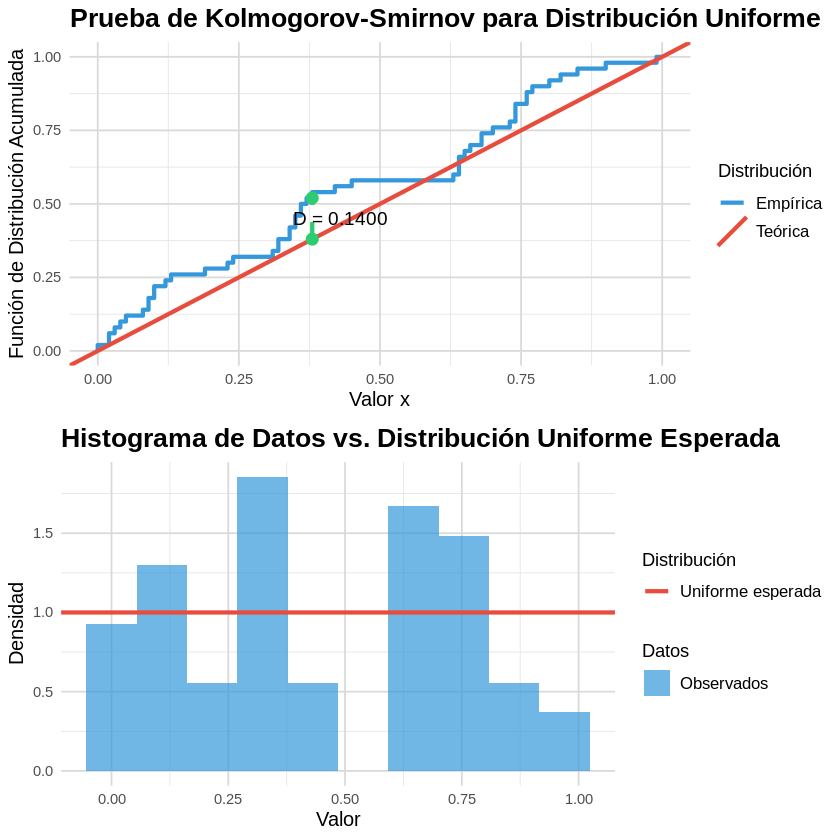

In [14]:
# Ejecutar prueba completa
resultadosKS <- EjecutarPruebaKS()